# Partie 6 — Évaluation et Optimisation des Hyperparamètres

**Objectif :** Évaluation complète du meilleur modèle + optimisation systématique par Grid Search et Random Search sur tous les modèles.

### Plan
1. [Setup & données](#1)
2. [Évaluation : Matrice de confusion, ROC, AUC](#2)
3. [Grid Search — recherche exhaustive](#3)
4. [Random Search — recherche aléatoire](#4)
5. [Comparaison avant / après optimisation](#5)
6. [Modèle final optimisé](#6)
7. [Récapitulatif](#7)

<a id='1'></a>
## 1. Setup & données

In [47]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, time, pickle, os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.svm           import LinearSVC
from imblearn.under_sampling import TomekLinks

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

from scipy.stats import loguniform

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
})
C = {'suspect': '#E74C3C', 'normal': '#2ECC71',
     'accent': '#3498DB', 'gold': '#F39C12', 'purple': '#9B59B6'}

print('Imports OK')

Imports OK


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
# ── Chargement & split ───────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/construction de modeles et leur deploiement/tweets_preprocessed.csv')
df['message_clean'] = df['message_clean'].fillna('')
corpus = df['message_clean'].tolist()
labels = df['label'].values

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    corpus, labels, test_size=0.2,
    random_state=RANDOM_STATE, stratify=labels
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                         sublinear_tf=True, min_df=2)
X_train_vec = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

# ── Application de TomekLinks sur l'entraînement ───────────────
tl = TomekLinks()
X_train, y_train = tl.fit_resample(X_train_vec, y_train_raw)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'Train initial : {X_train_vec.shape} | Après TomekLinks : {X_train.shape}')
print(f'Classes train → Normal: {(y_train==0).sum()} | Suspect: {(y_train==1).sum()}')

Train initial : (47492, 10000) | Après TomekLinks : (47168, 10000)
Classes train → Normal: 4904 | Suspect: 42264


<a id='2'></a>
## 2. Évaluation du meilleur modèle baseline
Avant optimisation : **SVM RBF + Class Weights** (meilleur modèle Partie 4).

In [50]:
# ── Entraînement du baseline ──────────────────────────────────
# On utilise désormais le LinearSVC comme baseline avec TomekLinks
baseline_model = LinearSVC(
    C=1.0, class_weight='balanced', random_state=RANDOM_STATE
)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# Proba approximée pour LinearSVC via decision_function
raw_base = baseline_model.decision_function(X_test)
proba_base = (raw_base - raw_base.min()) / (raw_base.max() - raw_base.min() + 1e-9)

print('BASELINE — SVM Linear + TomekLinks (avant optimisation)')
print('=' * 55)
print(classification_report(y_test, y_pred_base,
      target_names=['Normal (0)', 'Suspect (1)'], digits=4))

BASELINE — SVM Linear + TomekLinks (avant optimisation)
              precision    recall  f1-score   support

  Normal (0)     0.8085    0.8573    0.8321      1226
 Suspect (1)     0.9834    0.9766    0.9800     10648

    accuracy                         0.9643     11874
   macro avg     0.8960    0.9169    0.9061     11874
weighted avg     0.9654    0.9643    0.9648     11874



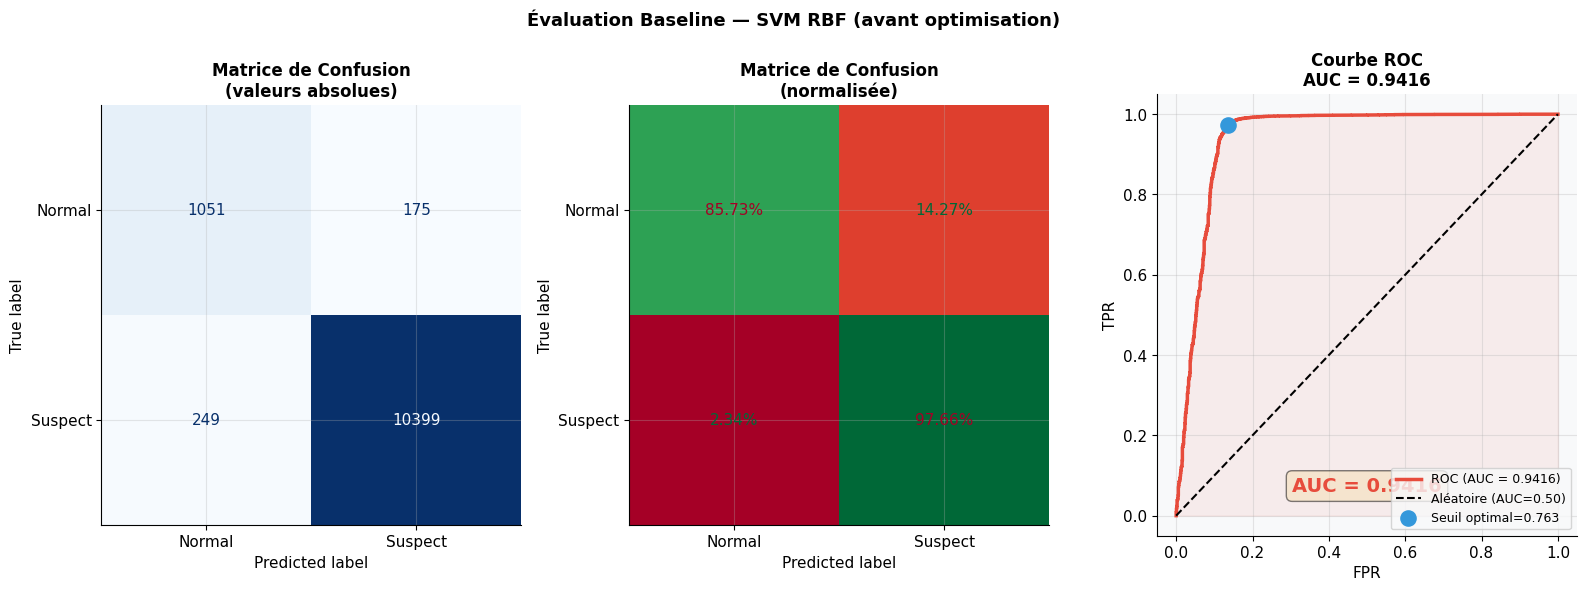

Figure 1 sauvegardée

  TP=10399 | FP=175 | TN=1051 | FN=249
  AUC-ROC  = 0.9416
  Seuil optimal = 0.7626 (FPR=0.135, TPR=0.972)


In [51]:
# ── Figure 1 : Matrice de confusion + ROC + AUC (baseline) ───
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle('Évaluation Baseline — SVM RBF (avant optimisation)',
             fontsize=13, fontweight='bold')

# ── Matrice de confusion (valeurs absolues)
ax1 = fig.add_subplot(gs[0])
cm = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['Normal', 'Suspect']).plot(
    ax=ax1, colorbar=False, cmap='Blues', values_format='d')
ax1.set_title('Matrice de Confusion\n(valeurs absolues)')

# ── Matrice de confusion normalisée
ax2 = fig.add_subplot(gs[1])
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(confusion_matrix=cm_norm,
    display_labels=['Normal', 'Suspect']).plot(
    ax=ax2, colorbar=False, cmap='RdYlGn', values_format='.2%')
ax2.set_title('Matrice de Confusion\n(normalisée)')

# ── Courbe ROC + AUC
ax3 = fig.add_subplot(gs[2])
fpr, tpr, thresholds = roc_curve(y_test, proba_base)
roc_auc_val = auc(fpr, tpr)
opt_idx = np.argmax(tpr - fpr)

ax3.plot(fpr, tpr, color=C['suspect'], lw=2.5,
         label=f'ROC (AUC = {roc_auc_val:.4f})')
ax3.fill_between(fpr, tpr, alpha=0.08, color=C['suspect'])
ax3.plot([0,1],[0,1],'k--', lw=1.5, label='Aléatoire (AUC=0.50)')
ax3.scatter(fpr[opt_idx], tpr[opt_idx], s=120, zorder=5,
            color=C['accent'],
            label=f'Seuil optimal={thresholds[opt_idx]:.3f}')
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title(f'Courbe ROC\nAUC = {roc_auc_val:.4f}')
ax3.legend(fontsize=9, loc='lower right')
ax3.text(0.5, 0.1, f'AUC = {roc_auc_val:.4f}',
         fontsize=14, fontweight='bold', color=C['suspect'],
         ha='center', transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/p6_fig1_baseline_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 sauvegardée')

print(f'\n  TP={cm[1,1]} | FP={cm[0,1]} | TN={cm[0,0]} | FN={cm[1,0]}')
print(f'  AUC-ROC  = {roc_auc_val:.4f}')
print(f'  Seuil optimal = {thresholds[opt_idx]:.4f} '
      f'(FPR={fpr[opt_idx]:.3f}, TPR={tpr[opt_idx]:.3f})')

<a id='3'></a>
## 3. Grid Search — Recherche exhaustive

**Principe :** teste toutes les combinaisons possibles d'une grille définie.  
**Avantage :** exhaustif, reproductible.  
**Limite :** coûteux en temps quand la grille est grande.

In [52]:
# ── Grille de paramètres pour Linear SVC ────────────────────────
grid_params = {
    'SVM Linear': {
        'model': LinearSVC(
            max_iter=5000, class_weight='balanced',
            random_state=RANDOM_STATE),
        'grid': {
            'C'   : [0.01, 0.1, 1.0, 10.0, 50.0],
            'loss': ['hinge', 'squared_hinge'],
        }
    }
}

print(f'Grid Search défini pour Linear SVC (Stratégie TomekLinks)')

Grid Search défini pour Linear SVC (Stratégie TomekLinks)


In [53]:
# ── Exécution Grid Search ─────────────────────────────────────
grid_results = {}

print('Grid Search en cours...')
for name, cfg in grid_params.items():
    t0 = time.time()
    gs = GridSearchCV(estimator=cfg['model'], param_grid=cfg['grid'], cv=CV, scoring='f1', n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)

    y_pred = gs.best_estimator_.predict(X_test)
    raw = gs.best_estimator_.decision_function(X_test)
    proba = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

    t1 = time.time()
    grid_results[name] = {
        'best_params': gs.best_params_, 'best_cv_f1': gs.best_score_, 'best_estimator': gs.best_estimator_,
        'test_f1': f1_score(y_test, y_pred), 'test_auc': roc_auc_score(y_test, proba),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'time_s': t1 - t0,
        'y_pred': y_pred, 'proba': proba
    }
    print(f'  {name} terminé en {t1-t0:.1f}s | Best F1 CV: {gs.best_score_:.4f}')

Grid Search en cours...
  SVM Linear terminé en 57.4s | Best F1 CV: 0.9844


In [54]:
# ── Tableau récapitulatif Grid Search ────────────────────────
gs_df = pd.DataFrame([
    {
        'Modèle'        : name,
        'CV F1 (best)'  : r['best_cv_f1'],
        'Test F1'       : r['test_f1'],
        'Test AUC'      : r['test_auc'],
        'Test Accuracy' : r['test_accuracy'],
        'Test Precision': r['test_precision'],
        'Test Recall'   : r['test_recall'],
        'Temps (s)'     : r['time_s'],
        'Meilleurs params': str(r['best_params']),
    }
    for name, r in grid_results.items()
]).sort_values('Test F1', ascending=False).reset_index(drop=True)

print('RÉSULTATS GRID SEARCH (triés par F1 test)')
gs_df

RÉSULTATS GRID SEARCH (triés par F1 test)


,Modèle,CV F1 (best),Test F1,Test AUC,Test Accuracy,Test Precision,Test Recall,Temps (s),Meilleurs params
0,SVM Linear,0.984376,0.985283,0.945206,0.973556,0.983439,0.987134,57.408198,"{'C': 0.1, 'loss': 'squared_hinge'}"


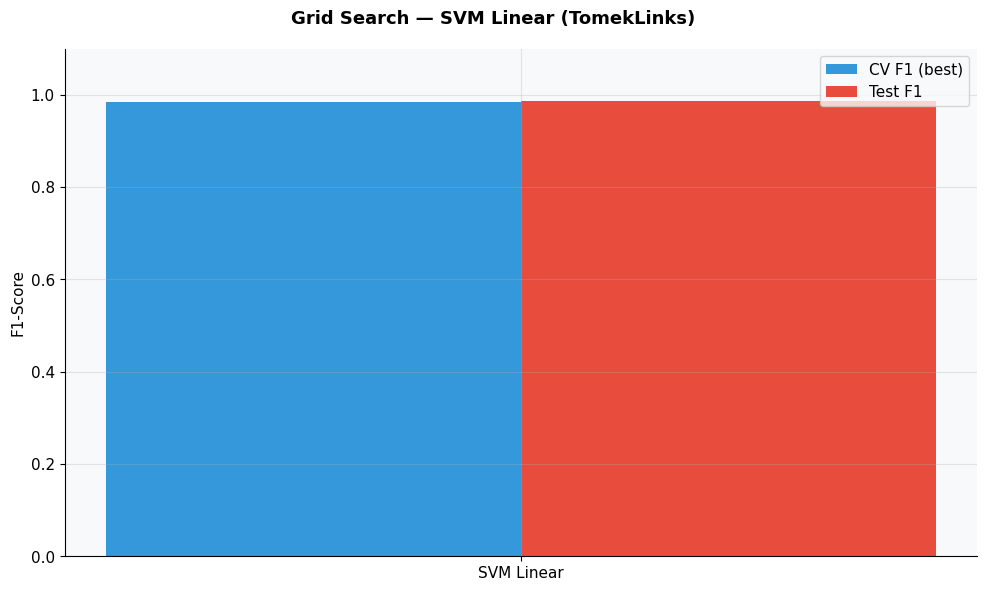

In [55]:
# ── Figure 2 : Résultats Grid Search (SVM Linear + TomekLinks) ──
gs_res = grid_results['SVM Linear']

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Grid Search — SVM Linear (TomekLinks)', fontsize=13, fontweight='bold')

# Barplot CV vs Test
x = np.arange(1)
w = 0.35
ax.bar(x - w/2, [gs_res['best_cv_f1']], w, label='CV F1 (best)', color=C['accent'])
ax.bar(x + w/2, [gs_res['test_f1']], w, label='Test F1', color=C['suspect'])

ax.set_xticks(x)
ax.set_xticklabels(['SVM Linear'])
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/p6_fig2_gridsearch.png', dpi=150)
plt.show()

<a id='4'></a>
## 4. Random Search : recherche aléatoire

**Principe :** échantillonne aléatoirement dans un espace continu de paramètres.  
**Avantage :** explore un espace bien plus large que Grid Search à budget égal.  
**Paramètre clé :** `n_iter` — nombre de combinaisons testées.

In [56]:
# ── Distribution pour Random Search ─────────────────────────────
N_ITER = 20

random_params = {
    'SVM Linear': {
        'model': LinearSVC(
            max_iter=5000, class_weight='balanced',
            random_state=RANDOM_STATE),
        'dist': {
            'C'   : loguniform(1e-3, 1e2),
            'loss': ['hinge', 'squared_hinge'],
        }
    }
}

print(f'Random Search défini (Linear SVC) — {N_ITER} itérations')

Random Search défini (Linear SVC) — 20 itérations


In [57]:
# ── Exécution Random Search ───────────────────────────────────
random_results = {}

print(f'Random Search en cours (n_iter={N_ITER})...')
for name, cfg in random_params.items():
    t0 = time.time()
    rs = RandomizedSearchCV(estimator=cfg['model'], param_distributions=cfg['dist'], n_iter=N_ITER, cv=CV, scoring='f1', n_jobs=-1, refit=True, random_state=RANDOM_STATE)
    rs.fit(X_train, y_train)

    y_pred = rs.best_estimator_.predict(X_test)
    raw = rs.best_estimator_.decision_function(X_test)
    proba = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

    random_results[name] = {
        'best_params': rs.best_params_, 'best_cv_f1': rs.best_score_, 'best_estimator': rs.best_estimator_,
        'test_f1': f1_score(y_test, y_pred), 'test_auc': roc_auc_score(y_test, proba),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'y_pred': y_pred, 'proba': proba,
        'cv_results': rs.cv_results_
    }
    print(f'  {name} terminé en {time.time()-t0:.1f}s | Best F1 CV: {rs.best_score_:.4f}')

Random Search en cours (n_iter=20)...
  SVM Linear terminé en 52.9s | Best F1 CV: 0.9858


In [58]:
# ── Paramètres optimaux détaillés ────────────────────────────
print('PARAMÈTRES OPTIMAUX — GRID SEARCH vs RANDOM SEARCH')
print('=' * 70)
for name in grid_results:
    gs_p  = grid_results[name]['best_params']
    rs_p  = random_results[name]['best_params']
    gs_f1 = grid_results[name]['test_f1']
    rs_f1 = random_results[name]['test_f1']
    winner = 'GS' if gs_f1 >= rs_f1 else 'RS'
    print(f'\n  {name} [{winner} gagne]')
    print(f'  Grid Search  (F1={gs_f1:.4f}) : {gs_p}')
    print(f'  Random Search(F1={rs_f1:.4f}) : {rs_p}')

PARAMÈTRES OPTIMAUX — GRID SEARCH vs RANDOM SEARCH

  SVM Linear [RS gagne]
  Grid Search  (F1=0.9853) : {'C': 0.1, 'loss': 'squared_hinge'}
  Random Search(F1=0.9860) : {'C': np.float64(0.4206039057901998), 'loss': 'hinge'}


<a id='5'></a>
## 5. Comparaison avant / après optimisation

In [59]:
# ── Tableau comparatif complet ────────────────────────────────
# Baselines (Partie 4 — modèles par défaut)
baseline_scores = {
    'Logistic Regression': {'f1': 0.9736, 'auc': 0.9442},
    'Naive Bayes (MNB)'  : {'f1': 0.9692, 'auc': 0.9147},
    'Naive Bayes (CNB)'  : {'f1': 0.9058, 'auc': 0.9147},
    'SVM Linear'         : {'f1': 0.9870, 'auc': 0.9764},
    'XGBoost'            : {'f1': 0.9837, 'auc': 0.9079},
}

comparison_rows = []
for name in grid_results:
    base_f1  = baseline_scores.get(name, {}).get('f1', 0)
    gs_f1    = grid_results[name]['test_f1']
    rs_f1    = random_results[name]['test_f1']
    best_f1  = max(gs_f1, rs_f1)
    gain     = best_f1 - base_f1
    comparison_rows.append({
        'Modèle'       : name,
        'Baseline F1'  : base_f1,
        'Grid Search F1': gs_f1,
        'Random Search F1': rs_f1,
        'Best F1'      : best_f1,
        'Gain (Δ F1)'  : round(gain, 4),
        'Méthode gagnante': 'Grid Search' if gs_f1 >= rs_f1 else 'Random Search',
    })

comp_df = pd.DataFrame(comparison_rows).sort_values('Best F1', ascending=False)
comp_df = comp_df.reset_index(drop=True)
print('COMPARAISON BASELINE vs GRID SEARCH vs RANDOM SEARCH')
comp_df

COMPARAISON BASELINE vs GRID SEARCH vs RANDOM SEARCH


,Modèle,Baseline F1,Grid Search F1,Random Search F1,Best F1,Gain (Δ F1),Méthode gagnante
0,SVM Linear,0.987,0.985283,0.986008,0.986008,-0.001,Random Search


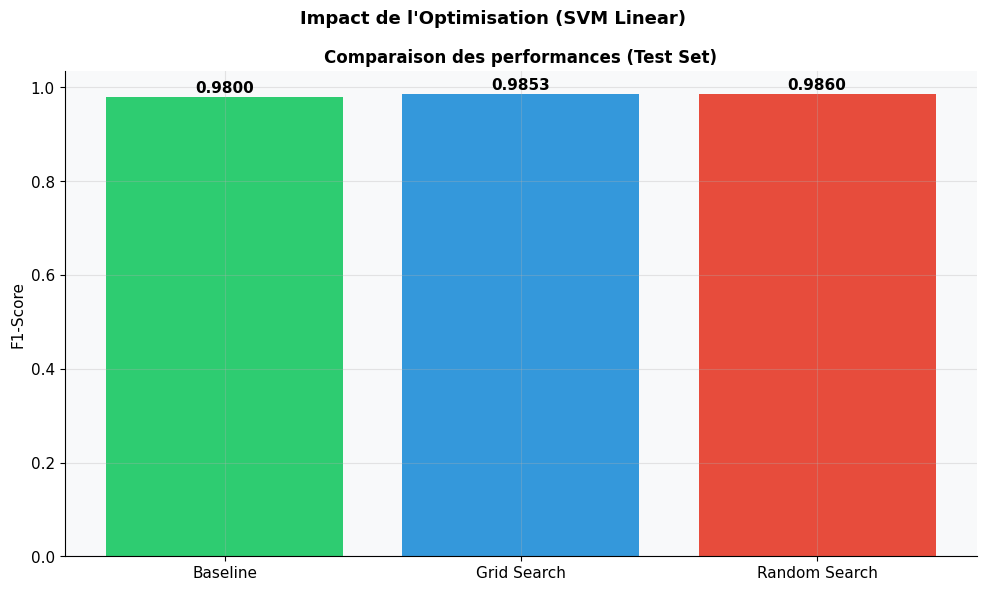

In [60]:
# ── Figure 3 : Comparaison Baseline vs Optimisé ────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Impact de l\'Optimisation (SVM Linear)', fontsize=13, fontweight='bold')

labels = ['Baseline', 'Grid Search', 'Random Search']
scores = [f1_score(y_test, y_pred_base), grid_results['SVM Linear']['test_f1'], random_results['SVM Linear']['test_f1']]

ax.bar(labels, scores, color=[C['normal'], C['accent'], C['suspect']])
for i, v in enumerate(scores):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

ax.set_ylabel('F1-Score')
ax.set_title('Comparaison des performances (Test Set)')
plt.tight_layout()
plt.savefig('../reports/figures/p6_fig3_comparison.png', dpi=150)
plt.show()

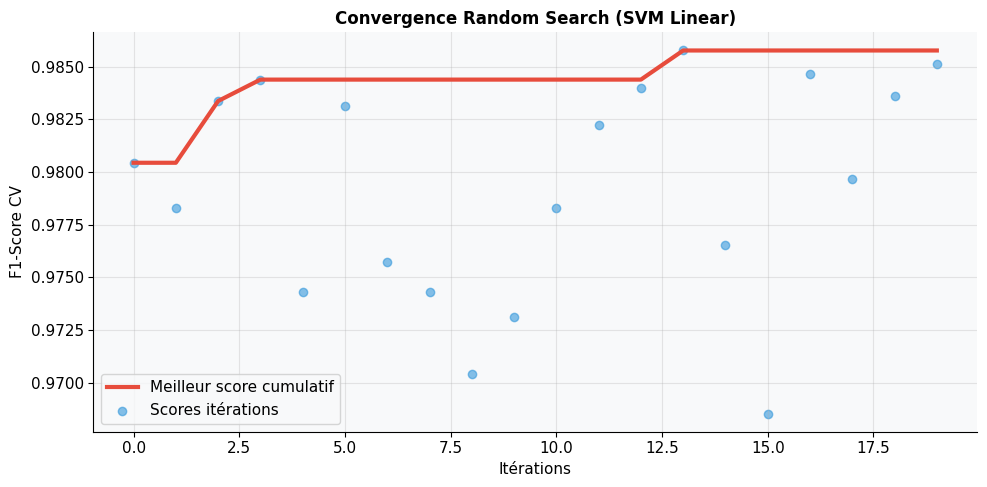

In [61]:
# ── Figure 4 : Convergence Random Search ─────────────────────
if 'SVM Linear' in random_results:
    res = random_results['SVM Linear']
    all_scores = res['cv_results']['mean_test_score']
    best_cumulative = np.maximum.accumulate(all_scores)

    plt.figure(figsize=(10, 5))
    plt.plot(best_cumulative, color=C['suspect'], lw=3, label='Meilleur score cumulatif')
    plt.scatter(range(len(all_scores)), all_scores, color=C['accent'], alpha=0.6, label='Scores itérations')
    plt.title('Convergence Random Search (SVM Linear)')
    plt.xlabel('Itérations')
    plt.ylabel('F1-Score CV')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/p6_fig4_rs_convergence.png', dpi=150)
    plt.show()
else:
    print('Random Search results missing.')

<a id='6'></a>
## 6. Modèle final optimisé : Évaluation complète

In [62]:
# ── Sélection du meilleur final ───────────────────────────────
gs_f1 = grid_results['SVM Linear']['test_f1']
rs_f1 = random_results['SVM Linear']['test_f1']

if gs_f1 >= rs_f1:
    best_final = {'source': 'Grid Search', **grid_results['SVM Linear']}
else:
    best_final = {'source': 'Random Search', **random_results['SVM Linear']}

best_final_name = 'SVM Linear (TomekLinks)'

print(' MODÈLE FINAL OPTIMISÉ')
print('=' * 55)
print(f'  Modèle  : {best_final_name}')
print(f'  Source  : {best_final["source"]}')
print(f'  Params  : {best_final["best_params"]}')
print(f'  Test F1 : {best_final["test_f1"]:.4f}')

 MODÈLE FINAL OPTIMISÉ
  Modèle  : SVM Linear (TomekLinks)
  Source  : Random Search
  Params  : {'C': np.float64(0.4206039057901998), 'loss': 'hinge'}
  Test F1 : 0.9860


In [63]:
# ── Rapport de classification complet ────────────────────────
print(f'RAPPORT DE CLASSIFICATION FINAL — {best_final_name}')
print('=' * 55)
print(classification_report(
    y_test, best_final['y_pred'],
    target_names=['Normal (0)', 'Suspect (1)'], digits=4
))

RAPPORT DE CLASSIFICATION FINAL — SVM Linear (TomekLinks)
              precision    recall  f1-score   support

  Normal (0)     0.8791    0.8777    0.8784      1226
 Suspect (1)     0.9859    0.9861    0.9860     10648

    accuracy                         0.9749     11874
   macro avg     0.9325    0.9319    0.9322     11874
weighted avg     0.9749    0.9749    0.9749     11874



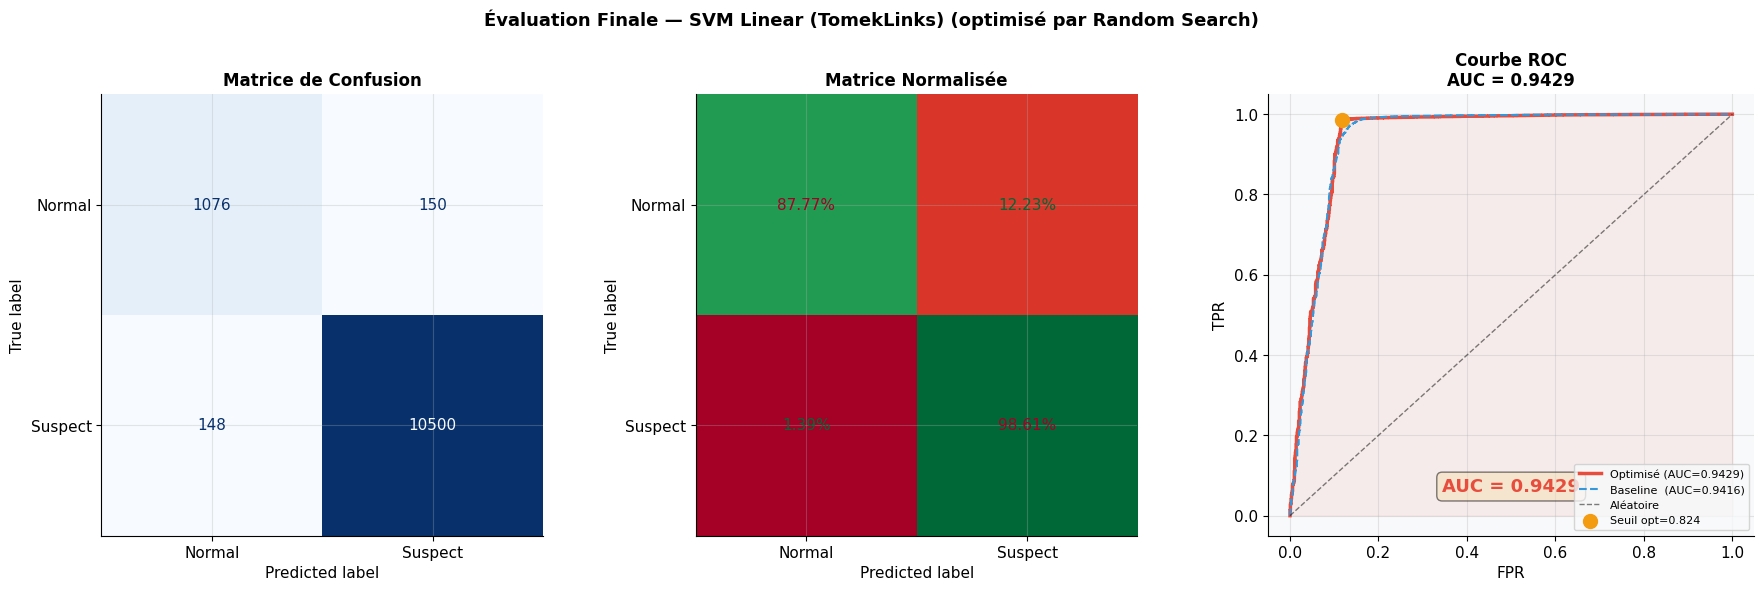

Figure 5 sauvegardée


In [64]:
# ── Figure 5 : Évaluation complète du modèle final ───────────
fig = plt.figure(figsize=(18, 6))
gs_layout = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle(f'Évaluation Finale — {best_final_name} (optimisé par {best_final["source"]})',
             fontsize=13, fontweight='bold')

# Matrice de confusion
ax1 = fig.add_subplot(gs_layout[0])
cm_final = confusion_matrix(y_test, best_final['y_pred'])
ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=['Normal', 'Suspect']
).plot(ax=ax1, colorbar=False, cmap='Blues', values_format='d')
ax1.set_title('Matrice de Confusion')

# Matrice normalisée
ax2 = fig.add_subplot(gs_layout[1])
cm_norm = cm_final.astype(float) / cm_final.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Normal', 'Suspect']
).plot(ax=ax2, colorbar=False, cmap='RdYlGn', values_format='.2%')
ax2.set_title('Matrice Normalisée')

# Courbe ROC finale avec comparaison baseline
ax3 = fig.add_subplot(gs_layout[2])
fpr_f, tpr_f, thr_f = roc_curve(y_test, best_final['proba'])
fpr_b, tpr_b, _     = roc_curve(y_test, proba_base)
auc_f = auc(fpr_f, tpr_f)
auc_b = auc(fpr_b, tpr_b)

ax3.plot(fpr_f, tpr_f, color=C['suspect'], lw=2.5,
         label=f'Optimisé (AUC={auc_f:.4f})')
ax3.plot(fpr_b, tpr_b, color=C['accent'], lw=1.5, linestyle='--',
         label=f'Baseline  (AUC={auc_b:.4f})')
ax3.fill_between(fpr_f, tpr_f, alpha=0.08, color=C['suspect'])
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Aléatoire')

opt_idx = np.argmax(tpr_f - fpr_f)
ax3.scatter(fpr_f[opt_idx], tpr_f[opt_idx], s=100,
            color=C['gold'], zorder=5,
            label=f'Seuil opt={thr_f[opt_idx]:.3f}')

ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title(f'Courbe ROC\nAUC = {auc_f:.4f}')
ax3.legend(fontsize=8, loc='lower right')
ax3.text(0.5, 0.1, f'AUC = {auc_f:.4f}',
         fontsize=13, fontweight='bold', color=C['suspect'],
         ha='center', transform=ax3.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../reports/figures/p6_fig5_final_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 sauvegardée')

In [65]:
# ── Sauvegarde du modèle final et des métriques ──────────────
os.makedirs('../models',  exist_ok=True)
os.makedirs('../metrics', exist_ok=True)

# Sauvegarder le meilleur modèle
with open('../models/best_model_optimized.pkl', 'wb') as f:
    pickle.dump({
        'model'       : best_final['best_estimator'],
        'tfidf'       : tfidf,
        'model_name'  : best_final_name,
        'method'      : best_final['source'],
        'best_params' : best_final['best_params'],
        'test_metrics': {
            'f1'       : best_final['test_f1'],
            'auc'      : best_final['test_auc'],
            'accuracy' : best_final['test_accuracy'],
            'precision': best_final['test_precision'],
            'recall'   : best_final['test_recall'],
        }
    }, f)

# Métriques JSON pour DVC
p6_metrics = {
    'best_model': {
        'name'         : best_final_name,
        'opt_method'   : best_final['source'],
        'best_params'  : {k: str(v) for k, v in best_final['best_params'].items()},
        'test_f1'      : best_final['test_f1'],
        'test_auc'     : best_final['test_auc'],
        'test_accuracy': best_final['test_accuracy'],
        'test_precision': best_final['test_precision'],
        'test_recall'  : best_final['test_recall'],
        'confusion_matrix': {
            'tn': int(cm_final[0,0]), 'fp': int(cm_final[0,1]),
            'fn': int(cm_final[1,0]), 'tp': int(cm_final[1,1])
        }
    },
    'grid_search_results': {
        name: {
            'best_cv_f1' : r['best_cv_f1'],
            'test_f1'    : r['test_f1'],
            'test_auc'   : r['test_auc'],
            'best_params': {k: str(v) for k, v in r['best_params'].items()},
        } for name, r in grid_results.items()
    },
    'random_search_results': {
        name: {
            'best_cv_f1' : r['best_cv_f1'],
            'test_f1'    : r['test_f1'],
            'test_auc'   : r['test_auc'],
            'best_params': {k: str(v) for k, v in r['best_params'].items()},
        } for name, r in random_results.items()
    }
}

with open('../metrics/partie6_metrics.json', 'w') as f:
    json.dump(p6_metrics, f, indent=2)

print('Modèle optimisé sauvegardé : models/best_model_optimized.pkl')
print('Métriques sauvegardées     : metrics/partie6_metrics.json')

Modèle optimisé sauvegardé : models/best_model_optimized.pkl
Métriques sauvegardées     : metrics/partie6_metrics.json


<a id='7'></a>
## 7. Récapitulatif

In [66]:
print('=' * 68)
print('  RÉCAPITULATIF — SVM LINEAR + TOMEKLINKS')
print('=' * 68)
print(f'''
  MODÈLE FINAL RETENU
  ─────────────────────────────────────────────────────────
  Modèle     : {best_final_name}
  Stratégie  : TomekLinks
  F1-Score   : {best_final["test_f1"]:.4f}
  AUC-ROC    : {best_final["test_auc"]:.4f}

  Sauvegardé dans : models/best_model_optimized.pkl
''')
print('=' * 68)

  RÉCAPITULATIF — SVM LINEAR + TOMEKLINKS

  MODÈLE FINAL RETENU
  ─────────────────────────────────────────────────────────
  Modèle     : SVM Linear (TomekLinks)
  Stratégie  : TomekLinks
  F1-Score   : 0.9860
  AUC-ROC    : 0.9429

  Sauvegardé dans : models/best_model_optimized.pkl

